In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

pybamm.set_logging_level("WARNING")

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.3.1


In [22]:
from pathlib import Path
import sys

# Make sure the project root is on sys.path
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root added to path:", PROJECT_ROOT)

Project root added to path: C:\GitHub\relaxation_diagnostics


In [23]:
from src.relaxation_utils import (
    make_experiment,
    make_model,
    make_base_params,
    make_storage_loss_params,
    detect_rest_start,
    extract_rest_window,
    compute_features,
    compute_all_windows,
    extract_component_rest_window,
    component_summaries,
)

print("Imported relaxation utilities successfully.")

Imported relaxation utilities successfully.


In [26]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [27]:
from src.relaxation_utils import (
    make_experiment,
    make_model,
    make_base_params,
    make_storage_loss_params,
    detect_rest_start,
    extract_rest_window,
    compute_features,
    compute_all_windows,
    extract_component_rest_window,
    component_summaries,
)

In [28]:
dense_delta_q_levels = [0.000, 0.025, 0.050, 0.075, 0.100, 0.125, 0.150, 0.175, 0.200]
dense_delta_q_levels

[0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2]

In [29]:
dense_feature_rows = []

for delta_q in dense_delta_q_levels:
    sim = pybamm.Simulation(
        make_model(),
        parameter_values=make_storage_loss_params(delta_q),
        experiment=make_experiment(),
    )
    sol = sim.solve()

    rest_t, rest_V, rest_start = extract_rest_window(sol, 120)

    feat = compute_all_windows(rest_t, rest_V)
    feat["label"] = f"storage_loss_{delta_q:.3f}Ah"
    feat["delta_q_ah"] = delta_q
    dense_feature_rows.append(feat)

dense_feature_sweep_df = pd.concat(dense_feature_rows, ignore_index=True)
dense_feature_sweep_df

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,log_time_slope_5_30_V_per_log_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.016659,0.003292,NaN,0.045241,storage_loss_0.000Ah,0.000
1,10,0.016659,0.003292,NaN,0.158046,storage_loss_0.000Ah,0.000
2,30,0.016659,0.003292,0.023689,1.010557,storage_loss_0.000Ah,0.000
3,60,0.016659,0.003292,0.023689,2.974103,storage_loss_0.000Ah,0.000
4,120,0.016659,0.003292,0.023689,8.073539,storage_loss_0.000Ah,0.000
5,5,0.016791,0.003317,NaN,0.045619,storage_loss_0.025Ah,0.025
6,10,0.016791,0.003317,NaN,0.159281,storage_loss_0.025Ah,0.025
7,30,0.016791,0.003317,0.023852,1.017929,storage_loss_0.025Ah,0.025
8,60,0.016791,0.003317,0.023852,2.996882,storage_loss_0.025Ah,0.025
9,120,0.016791,0.003317,0.023852,8.142323,storage_loss_0.025Ah,0.025


In [30]:
dense_feature_sweep_df.to_csv("../outputs/dense_feature_sweep_storage_loss.csv", index=False)
print("Saved dense feature sweep table.")

Saved dense feature sweep table.


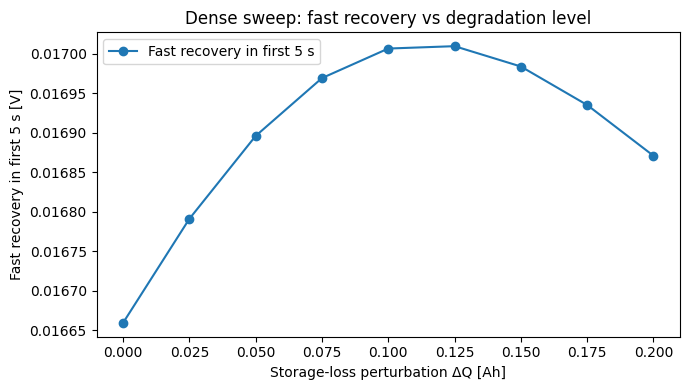

In [31]:
plt.figure(figsize=(7, 4))

sub = dense_feature_sweep_df[dense_feature_sweep_df["window_s"] == 5].copy()
sub = sub.sort_values("delta_q_ah")

plt.plot(
    sub["delta_q_ah"],
    sub["fast_recovery_5s_V"],
    marker="o",
    label="Fast recovery in first 5 s"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Fast recovery in first 5 s [V]")
plt.title("Dense sweep: fast recovery vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

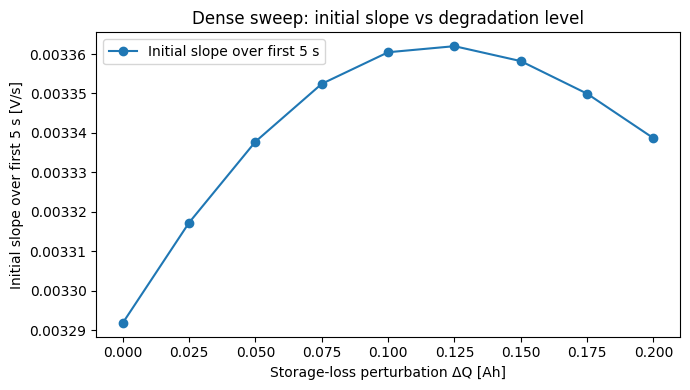

In [32]:
plt.figure(figsize=(7, 4))

sub = dense_feature_sweep_df[dense_feature_sweep_df["window_s"] == 5].copy()
sub = sub.sort_values("delta_q_ah")

plt.plot(
    sub["delta_q_ah"],
    sub["initial_slope_0_5_V_per_s"],
    marker="o",
    label="Initial slope over first 5 s"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Initial slope over first 5 s [V/s]")
plt.title("Dense sweep: initial slope vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

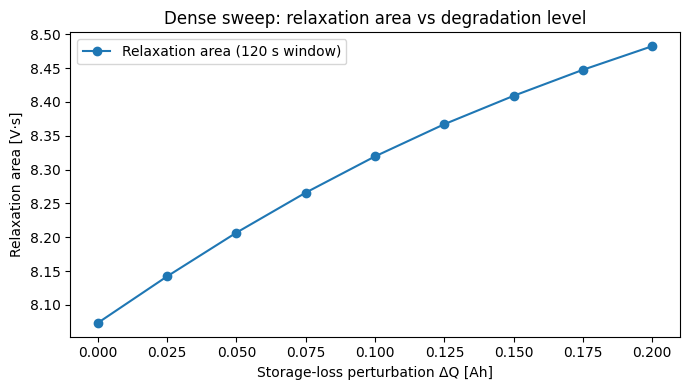

In [33]:
plt.figure(figsize=(7, 4))

sub = dense_feature_sweep_df[dense_feature_sweep_df["window_s"] == 120].copy()
sub = sub.sort_values("delta_q_ah")

plt.plot(
    sub["delta_q_ah"],
    sub["relaxation_area_Vs"],
    marker="o",
    label="Relaxation area (120 s window)"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Relaxation area [V·s]")
plt.title("Dense sweep: relaxation area vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

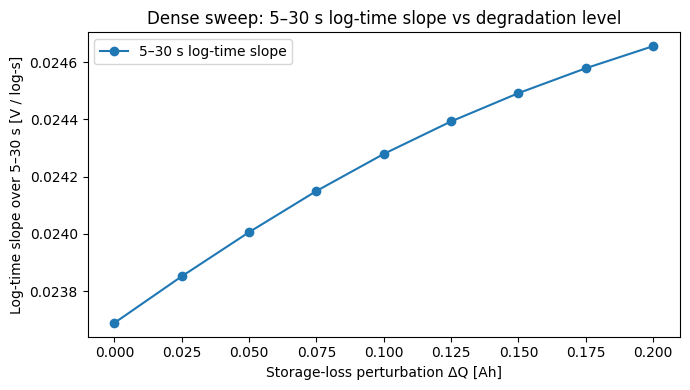

In [34]:
plt.figure(figsize=(7, 4))

sub = dense_feature_sweep_df[dense_feature_sweep_df["window_s"] == 30].copy()
sub = sub.sort_values("delta_q_ah")

plt.plot(
    sub["delta_q_ah"],
    sub["log_time_slope_5_30_V_per_log_s"],
    marker="o",
    label="5–30 s log-time slope"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Log-time slope over 5–30 s [V / log-s]")
plt.title("Dense sweep: 5–30 s log-time slope vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
dense_component_rows = []

for delta_q in dense_delta_q_levels:
    sim = pybamm.Simulation(
        make_model(),
        parameter_values=make_storage_loss_params(delta_q),
        experiment=make_experiment(),
    )
    sol = sim.solve()

    comp = extract_component_rest_window(sol, 120)
    comp_df = pd.DataFrame(comp)

    row = component_summaries(comp_df)
    row["delta_q_ah"] = delta_q
    dense_component_rows.append(row)

dense_component_sweep_df = pd.DataFrame(dense_component_rows)
dense_component_sweep_df

,Reaction overpotential [V]__start,Reaction overpotential [V]__end_5s,Reaction overpotential [V]__end_30s,Reaction overpotential [V]__drop_0_5s,Reaction overpotential [V]__drop_5_30s,Solid ohmic losses [V]__start,Solid ohmic losses [V]__end_5s,Solid ohmic losses [V]__end_30s,Solid ohmic losses [V]__drop_0_5s,Solid ohmic losses [V]__drop_5_30s,...,Electrolyte ohmic losses [V]__end_5s,Electrolyte ohmic losses [V]__end_30s,Electrolyte ohmic losses [V]__drop_0_5s,Electrolyte ohmic losses [V]__drop_5_30s,Concentration overpotential [V]__start,Concentration overpotential [V]__end_5s,Concentration overpotential [V]__end_30s,Concentration overpotential [V]__drop_0_5s,Concentration overpotential [V]__drop_5_30s,delta_q_ah
0,0.000232,0.000345,0.000453,-0.000113,-0.000108,0.000117,0.000155,0.000165,-0.000038,-9.881253e-06,...,-0.000449,-0.000599,-0.000105,0.000150,-0.034939,-0.029638,-0.015341,-0.005302,-0.014296,0.000
1,0.000105,0.000245,0.000439,-0.000139,-0.000195,0.000119,0.000158,0.000166,-0.000038,-8.426028e-06,...,-0.000405,-0.000568,-0.000098,0.000162,-0.035559,-0.030214,-0.015808,-0.005344,-0.014406,0.025
2,-0.000036,0.000128,0.000413,-0.000163,-0.000285,0.000122,0.000160,0.000167,-0.000038,-6.937949e-06,...,-0.000356,-0.000531,-0.000090,0.000175,-0.036218,-0.030828,-0.016305,-0.005390,-0.014523,0.050
3,-0.000188,-0.000005,0.000373,-0.000183,-0.000377,0.000124,0.000162,0.000168,-0.000038,-5.409375e-06,...,-0.000299,-0.000489,-0.000083,0.000190,-0.036917,-0.031479,-0.016833,-0.005438,-0.014645,0.075
4,-0.000347,-0.000150,0.000319,-0.000197,-0.000469,0.000127,0.000165,0.000169,-0.000038,-3.820799e-06,...,-0.000237,-0.000443,-0.000078,0.000205,-0.037661,-0.032173,-0.017398,-0.005488,-0.014775,0.100
5,-0.000509,-0.000304,0.000255,-0.000206,-0.000559,0.000129,0.000167,0.000170,-0.000038,-2.174099e-06,...,-0.000171,-0.000392,-0.000073,0.000221,-0.038453,-0.032913,-0.018002,-0.005540,-0.014911,0.125
6,-0.000672,-0.000464,0.000180,-0.000208,-0.000644,0.000132,0.000170,0.000171,-0.000038,-4.879742e-07,...,-0.000099,-0.000336,-0.000071,0.000237,-0.039295,-0.033701,-0.018646,-0.005594,-0.015055,0.150
7,-0.000834,-0.000629,0.000094,-0.000205,-0.000723,0.000136,0.000173,0.000172,-0.000038,1.275529e-06,...,-0.000025,-0.000277,-0.000070,0.000252,-0.040191,-0.034540,-0.019335,-0.005650,-0.015206,0.175
8,-0.000991,-0.000793,0.000001,-0.000197,-0.000794,0.000139,0.000177,0.000174,-0.000037,3.093184e-06,...,0.000053,-0.000216,-0.000070,0.000268,-0.041146,-0.035437,-0.020070,-0.005709,-0.015367,0.200


In [36]:
dense_component_sweep_df.to_csv("../outputs/dense_component_sweep_storage_loss.csv", index=False)
print("Saved dense component sweep table.")

Saved dense component sweep table.


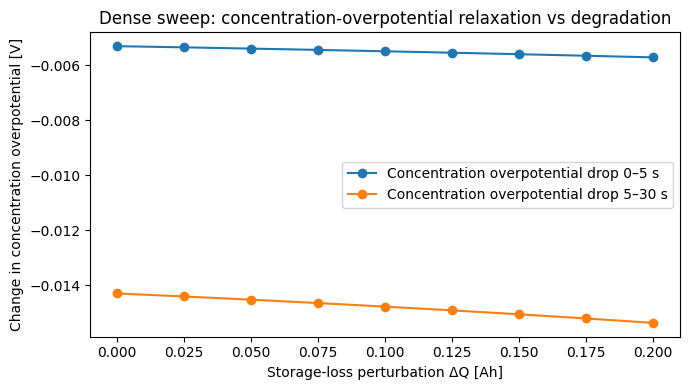

In [37]:
plt.figure(figsize=(7, 4))

plt.plot(
    dense_component_sweep_df["delta_q_ah"],
    dense_component_sweep_df["Concentration overpotential [V]__drop_0_5s"],
    marker="o",
    label="Concentration overpotential drop 0–5 s"
)

plt.plot(
    dense_component_sweep_df["delta_q_ah"],
    dense_component_sweep_df["Concentration overpotential [V]__drop_5_30s"],
    marker="o",
    label="Concentration overpotential drop 5–30 s"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Change in concentration overpotential [V]")
plt.title("Dense sweep: concentration-overpotential relaxation vs degradation")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
dense_feature_30 = dense_feature_sweep_df[dense_feature_sweep_df["window_s"] == 30].copy()

dense_comparison_mech = pd.merge(
    dense_feature_30[["delta_q_ah", "log_time_slope_5_30_V_per_log_s"]],
    dense_component_sweep_df[[
        "delta_q_ah",
        "Concentration overpotential [V]__drop_5_30s"
    ]],
    on="delta_q_ah"
)

dense_comparison_mech

,delta_q_ah,log_time_slope_5_30_V_per_log_s,Concentration overpotential [V]__drop_5_30s
0,0.000,0.023689,-0.014296
1,0.025,0.023852,-0.014406
2,0.050,0.024006,-0.014523
3,0.075,0.024150,-0.014645
4,0.100,0.024279,-0.014775
5,0.125,0.024393,-0.014911
6,0.150,0.024491,-0.015055
7,0.175,0.024578,-0.015206
8,0.200,0.024655,-0.015367


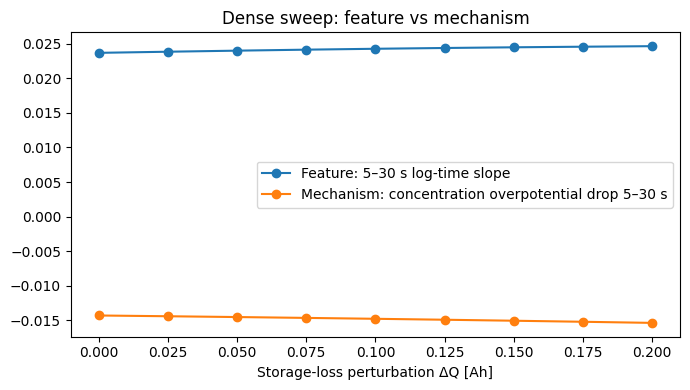

In [39]:
plt.figure(figsize=(7, 4))

plt.plot(
    dense_comparison_mech["delta_q_ah"],
    dense_comparison_mech["log_time_slope_5_30_V_per_log_s"],
    marker="o",
    label="Feature: 5–30 s log-time slope"
)

plt.plot(
    dense_comparison_mech["delta_q_ah"],
    dense_comparison_mech["Concentration overpotential [V]__drop_5_30s"],
    marker="o",
    label="Mechanism: concentration overpotential drop 5–30 s"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.title("Dense sweep: feature vs mechanism")
plt.legend()
plt.tight_layout()
plt.show()

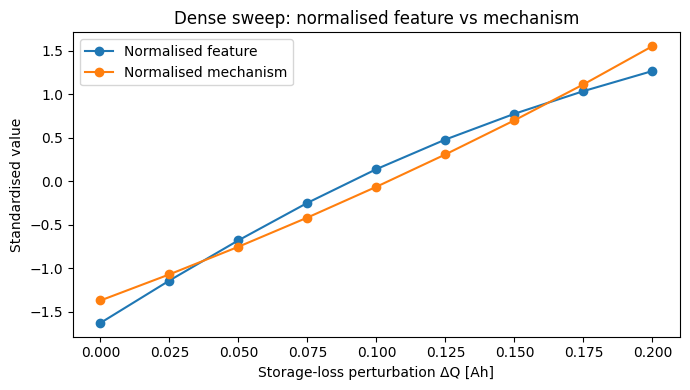

In [40]:
dense_plot_df = dense_comparison_mech.copy()
dense_plot_df["feature_norm"] = (
    dense_plot_df["log_time_slope_5_30_V_per_log_s"] - dense_plot_df["log_time_slope_5_30_V_per_log_s"].mean()
) / dense_plot_df["log_time_slope_5_30_V_per_log_s"].std()

dense_plot_df["mechanism_norm"] = (
    (-dense_plot_df["Concentration overpotential [V]__drop_5_30s"]) - (-dense_plot_df["Concentration overpotential [V]__drop_5_30s"]).mean()
) / (-dense_plot_df["Concentration overpotential [V]__drop_5_30s"]).std()

plt.figure(figsize=(7, 4))
plt.plot(
    dense_plot_df["delta_q_ah"],
    dense_plot_df["feature_norm"],
    marker="o",
    label="Normalised feature"
)
plt.plot(
    dense_plot_df["delta_q_ah"],
    dense_plot_df["mechanism_norm"],
    marker="o",
    label="Normalised mechanism"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Standardised value")
plt.title("Dense sweep: normalised feature vs mechanism")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
dense_comparison_mech.corr(numeric_only=True)

,delta_q_ah,log_time_slope_5_30_V_per_log_s,Concentration overpotential [V]__drop_5_30s
delta_q_ah,1.000000,0.992371,-0.998198
log_time_slope_5_30_V_per_log_s,0.992371,1.000000,-0.983200
Concentration overpotential [V]__drop_5_30s,-0.998198,-0.983200,1.000000


In [42]:
dense_comparison_mech.to_csv("../outputs/dense_feature_vs_mechanism_comparison.csv", index=False)
print("Saved dense feature-mechanism comparison table.")

Saved dense feature-mechanism comparison table.
